## Cell 1: Check GPU Availability

In [1]:
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

PyTorch version: 2.9.0+cu126
CUDA available: True
GPU: Tesla T4
GPU Memory: 15.83 GB


## Cell 3: Clone Repository from GitHub

In [ ]:
# Clone from GitHub or pull latest changes
import os
if not os.path.exists('ml_engine'):
    !git clone https://github.com/Raynergy-svg/ml_engine.git
    print("✓ Repository cloned successfully")
else:
    print("✓ Repository exists, pulling latest changes...")
    %cd ml_engine
    !git pull origin main
    print("✓ Repository updated")
    %cd ..

%cd ml_engine
print(f"✓ Working directory: {os.getcwd()}")

Cloning into 'ml_engine'...
remote: Enumerating objects: 482, done.
remote: Counting objects: 100% (482/482), done.
remote: Enumerating objects: 482, done.)
remote: Counting objects: 100% (482/482), done.
remote: Compressing objects: 100% (327/327), done.
remote: Compressing objects: 100% (327/327), done.
remote: Total 482 (delta 230), reused 383 (delta 134), pack-reused 0 (from 0)
Receiving objects: 100% (482/482), 19.70 MiB | 12.34 MiB/s, done.
Resolving deltas: 100% (230/230), done.
remote: Total 482 (delta 230), reused 383 (delta 134), pack-reused 0 (from 0)
Receiving objects: 100% (482/482), 19.70 MiB | 12.34 MiB/s, done.
Resolving deltas: 100% (230/230), done.
/content/ml_engine
/content/ml_engine


## Cell 6: Install Dependencies

In [6]:
!pip install -q torch numpy pandas scikit-learn pyyaml tqdm rich matplotlib seaborn

## Cell 8: Update Config for GPU Training

In [9]:
import yaml

# Load config
with open('config.yaml', 'r') as f:
    config = yaml.safe_load(f)

# Update for GPU and faster training
config['device'] = 'cuda' if torch.cuda.is_available() else 'cpu'
config['batch_size'] = 128  # Larger batch size for GPU
config['epochs'] = 100  # Adjust as needed
config['auto_resume'] = True  # Enable auto-resume
config['mixed_precision'] = True  # Enable mixed precision for faster training
config['early_stopping_patience'] = 20

# Save updated config
with open('config.yaml', 'w') as f:
    yaml.dump(config, f)

print("Config updated:")
print(f"  Device: {config['device']}")
print(f"  Batch size: {config['batch_size']}")
print(f"  Epochs: {config['epochs']}")

Config updated:
  Device: cuda
  Batch size: 128
  Epochs: 100


## Cell 10: Train the Model (With Technical Indicators)

This cell will:
- Load all CSV files from market_data/
- Enable feature engineering (SMA, EMA, RSI, MACD, Bollinger Bands, etc.)
- Add 50+ technical indicators for better predictions
- Train the model with enhanced features

In [34]:
from ml_engine_enhanced import EnhancedMLEngine
from data_loader import MarketDataLoader
from utils import load_config
import numpy as np
import pandas as pd
import glob

# Load config
config = load_config('config.yaml')

# Load market data from all CSV files (exclude predictions file)
print("Loading market data...")
csv_files = glob.glob('market_data/*.csv')
csv_files = [f for f in csv_files if 'predictions' not in f]  # Skip predictions files
print(f"Found {len(csv_files)} CSV files")

if not csv_files:
    raise ValueError("No CSV files found in market_data/ folder.")

# Load and combine all CSV files with proper datetime handling
dfs = []
for file in csv_files:
    print(f"Loading {file}...")
    df = pd.read_csv(file)
    
    # Standardize column names to lowercase
    df.columns = df.columns.str.lower()
    
    # Convert date column to datetime and set as index
    if 'date' in df.columns:
        df['date'] = pd.to_datetime(df['date'])
        df.set_index('date', inplace=True)
    elif 'datetime' in df.columns:
        df['datetime'] = pd.to_datetime(df['datetime'])
        df.set_index('datetime', inplace=True)
    
    # Ensure index is datetime type for feature engineering
    if not isinstance(df.index, pd.DatetimeIndex):
        print(f"WARNING: {file} does not have datetime index, attempting conversion...")
        df.index = pd.to_datetime(df.index)
    
    if 'symbol' not in df.columns:
        # Add symbol from filename
        symbol = file.split('/')[-1].replace('_data.csv', '').replace('.csv', '')
        df['symbol'] = symbol
    
    dfs.append(df)

df = pd.concat(dfs, ignore_index=False)
print(f"Loaded {len(df)} data points from {df['symbol'].nunique()} tickers")
print(f"Date range: {df.index.min()} to {df.index.max()}")
print(f"Columns: {list(df.columns)}")

# Enable feature engineering for better performance
print("\n" + "="*60)
print("ENABLING TECHNICAL INDICATORS")
print("="*60)
print("Adding: SMA, EMA, RSI, MACD, Bollinger Bands, ATR, CCI, OBV, MFI, etc.")

data_loader = MarketDataLoader(config)

# Try with feature engineering enabled
try:
    result = data_loader.preprocess(df, add_features=True)
    print("✓ Feature engineering successful!")
except Exception as e:
    print(f"✗ Feature engineering failed: {e}")
    print("Falling back to basic features...")
    result = data_loader.preprocess(df, add_features=False)

# Handle different return formats (6-tuple expected from preprocess)
if isinstance(result, tuple) and len(result) == 6:
    X_train, y_train, X_val, y_val, X_test, y_test = result
    print(f"\nData split complete:")
    print(f"  Train: X={X_train.shape}, y={y_train.shape}")
    print(f"  Val: X={X_val.shape}, y={y_val.shape}")
    print(f"  Test: X={X_test.shape}, y={y_test.shape}")
    print(f"  Features per timestep: {X_train.shape[2]}")
else:
    raise ValueError(f"Unexpected preprocess return format: {type(result)}, length: {len(result) if isinstance(result, tuple) else 'N/A'}")

# Update model config with correct input size
if 'model' not in config:
    config['model'] = {}
config['model']['input_size'] = X_train.shape[2]

print("\n" + "="*60)
print("INITIALIZING MODEL")
print("="*60)
print(f"Input size: {config['model']['input_size']} features")
print(f"Sequence length: 60 timesteps")
print(f"Device: {config['device']}")

# Create engine and train
engine = EnhancedMLEngine(config)

print("\n" + "="*60)
print("STARTING TRAINING")
print("="*60)
result = engine.train(
    X_train, y_train,
    X_val, y_val,
    epochs=config['epochs']
)

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Resumed: {result.get('resumed', False)}")
print(f"Total epochs: {result.get('total_epochs', 'N/A')}")
print(f"Best validation loss: {result['best_val_loss']:.6f}")
print(f"Final train loss: {result['train_losses'][-1]:.6f}")
print(f"Final val loss: {result['val_losses'][-1]:.6f}")

Loading market data...
Found 5 CSV files
Loading market_data/ORCL_data.csv...


/tmp/ipython-input-965365029.py:31: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df['date'] = pd.to_datetime(df['date'])


ValueError: Tz-aware datetime.datetime cannot be converted to datetime64 unless utc=True, at position 32

## Cell 12: Plot Training History

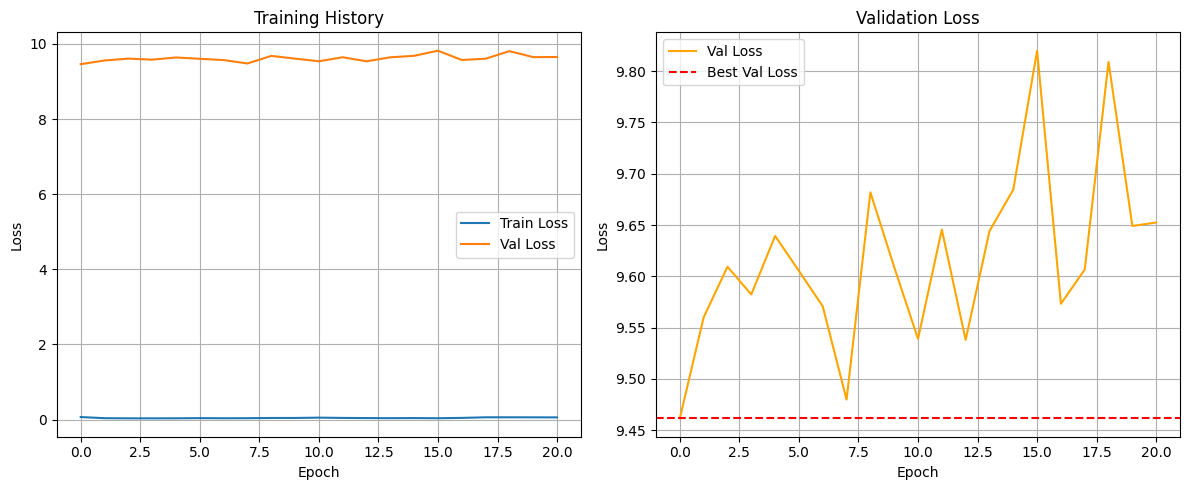

In [30]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(result['train_losses'], label='Train Loss')
plt.plot(result['val_losses'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training History')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(result['val_losses'], label='Val Loss', color='orange')
plt.axhline(y=result['best_val_loss'], color='r', linestyle='--', label='Best Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Validation Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

## Cell 14: Evaluate Model

In [33]:
# Evaluate on validation set
metrics = engine.evaluate(X_val, y_val)

print("Validation Metrics:")
for key, value in metrics.items():
    print(f"  {key}: {value:.6f}")

Validation Metrics:
  mse: 119.875320
  rmse: 10.948759
  mae: 8.798479
  r2_score: -1.663594


## Cell 16: Download Trained Model (After All Training)

In [32]:
from google.colab import files
import shutil
import os

# Create a zip file with all trained models
shutil.make_archive('trained_models', 'zip', 'trained_data/models')

# Download
files.download('trained_models.zip')

print("\nDownload complete! Extract and place in your local trained_data/models/ folder.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Download complete! Extract and place in your local trained_data/models/ folder.


---

## Automated Execution Guide

**Just click "Run All" and let it run!**

**First Run** - Complete setup and training:
1. Cells 1-2: Check GPU availability
2. Cell 4: Clone repository from GitHub
3. Cell 7: Install dependencies  
4. Cell 9: Configure for GPU training
5. Cell 11: Train with 50+ technical indicators (100 epochs)
6. Cell 13: Plot training history
7. Cell 15: Evaluate model performance
8. Cell 17: Download trained model
9. Cell 19: Extended training (5 sessions × 100 epochs = 500 total)

**Subsequent "Run All"** - Continuous improvement:
- Skips cloning (repo already exists)
- Auto-resumes from best checkpoint
- Trains for another 100 epochs (Cell 11)
- Updates plots and metrics
- Extended training session (Cell 19)
- Downloads improved model

**Note**: Each "Run All" automatically continues from your best model checkpoint, progressively improving predictions.

In [31]:
# Continuous Improvement Loop
# This will train multiple sessions, always resuming from best checkpoint
import time

num_training_sessions = 5  # Number of training cycles
epochs_per_session = 100   # Epochs per cycle

print("="*60)
print("CONTINUOUS TRAINING LOOP")
print("="*60)
print(f"Sessions: {num_training_sessions}")
print(f"Epochs per session: {epochs_per_session}")
print(f"Total epochs: {num_training_sessions * epochs_per_session}")
print("="*60)

for session in range(1, num_training_sessions + 1):
    print(f"\n{'='*60}")
    print(f"SESSION {session}/{num_training_sessions}")
    print(f"{'='*60}")
    
    start_time = time.time()
    
    # Train for more epochs (auto-resumes from best checkpoint)
    result = engine.train(
        X_train, y_train,
        X_val, y_val,
        epochs=epochs_per_session
    )
    
    elapsed = time.time() - start_time
    
    print(f"\nSession {session} Complete (took {elapsed/60:.1f} minutes)")
    print(f"  Resumed: {result.get('resumed', False)}")
    print(f"  Total epochs: {result.get('total_epochs', 'N/A')}")
    print(f"  Best val loss: {result['best_val_loss']:.6f}")
    print(f"  Final train loss: {result['train_losses'][-1]:.6f}")
    print(f"  Final val loss: {result['val_losses'][-1]:.6f}")
    
    # Check for early stopping across sessions
    if result.get('stopped_early', False):
        print(f"\n✓ Early stopping triggered at session {session}")
        print("  Model has converged - no further improvement expected")
        break

print("\n" + "="*60)
print("CONTINUOUS TRAINING COMPLETE")
print("="*60)
print("Best model saved at: trained_data/models/best_model.pth")
print("="*60)

CONTINUOUS TRAINING LOOP
Sessions: 5
Epochs per session: 100
Total epochs: 500

SESSION 1/5

Session 1 Complete (took 0.2 minutes)
  Resumed: True
  Total epochs: 100
  Best val loss: 9.436414
  Final train loss: 0.085072
  Final val loss: 9.642225

SESSION 2/5

Session 1 Complete (took 0.2 minutes)
  Resumed: True
  Total epochs: 100
  Best val loss: 9.436414
  Final train loss: 0.085072
  Final val loss: 9.642225

SESSION 2/5

Session 2 Complete (took 0.2 minutes)
  Resumed: True
  Total epochs: 100
  Best val loss: 9.412729
  Final train loss: 0.049343
  Final val loss: 9.595044

SESSION 3/5

Session 2 Complete (took 0.2 minutes)
  Resumed: True
  Total epochs: 100
  Best val loss: 9.412729
  Final train loss: 0.049343
  Final val loss: 9.595044

SESSION 3/5

Session 3 Complete (took 0.1 minutes)
  Resumed: True
  Total epochs: 100
  Best val loss: 9.490729
  Final train loss: 0.045858
  Final val loss: 9.919562

SESSION 4/5

Session 3 Complete (took 0.1 minutes)
  Resumed: True
  T

---

## Tips for Free GPU Training

**Google Colab Free Tier:**
- GPU: Tesla T4 (16GB)
- Session timeout: ~12 hours
- Auto-disconnect after ~90 min idle

**To maximize free GPU time:**
1. Keep the tab active (prevents idle disconnect)
2. Use auto-resume (enabled in config) so you can restart if disconnected
3. Download checkpoints periodically (Cell 17)
4. Consider Colab Pro ($10/mo) for longer sessions and better GPUs

**Training Strategy:**
- Run Cell 11 first (initial 100 epochs with 50+ technical indicators) → ~10-15 minutes
- Check results with Cells 13 & 15
- Run Cell 19 for extended training (500 epochs) → ~30-60 minutes
- Download final model with Cell 17

**Alternatives:**
- **Kaggle Notebooks**: 30 hrs/week free GPU
- **Paperspace Gradient**: Free tier with 6hr sessions
- **Lightning AI**: Free tier available